In [124]:
import nfl_data_py as nfl
import pandas as pd

In [125]:
# make data set much larger by using to pass_tds_next_season or maybe look at smth like wins_nxt_season

In [127]:
df = nfl.import_ngs_data(stat_type='passing', years = [2024])
df = df[df['season_type'] == 'REG'].sort_values(by = 'attempts', ascending = False)
df = df[df['attempts'] > 100]
df.columns

Index(['season', 'season_type', 'week', 'player_display_name',
       'player_position', 'team_abbr', 'avg_time_to_throw',
       'avg_completed_air_yards', 'avg_intended_air_yards',
       'avg_air_yards_differential', 'aggressiveness',
       'max_completed_air_distance', 'avg_air_yards_to_sticks', 'attempts',
       'pass_yards', 'pass_touchdowns', 'interceptions', 'passer_rating',
       'completions', 'completion_percentage',
       'expected_completion_percentage',
       'completion_percentage_above_expectation', 'avg_air_distance',
       'max_air_distance', 'player_gsis_id', 'player_first_name',
       'player_last_name', 'player_jersey_number', 'player_short_name'],
      dtype='object')

In [ ]:
def create_table(year):
    df = nfl.import_ngs_data(stat_type = 'passing', years = [year])
    df = df[df['attempts'] > 100]
    df = df[['player_display_name', 'season','aggressiveness', 'pass_yards', 'completions', 
             'interceptions', 'pass_touchdowns']]

    mdf = nfl.import_ngs_data(stat_type = 'passing', years = [year + 1])
    mdf = mdf[mdf['attempts'] > 100]
    mdf = mdf[['player_display_name', 'pass_touchdowns']]
    mdf = mdf.rename(columns = {'pass_touchdowns':'touchdowns_next'})
    merged = pd.merge(df, mdf, on='player_display_name', how = 'left')
    merged = merged.dropna()
    merged['twenty_next'] = (merged['touchdowns_next'] >= 20).astype(int)
    return merged

create_table(2024)

,player_display_name,season,aggressiveness,pass_yards,completions,interceptions,pass_touchdowns,touchdowns_next,twenty_next
0,Justin Herbert,2024,15.873016,3870,332,3,23,26.0,1
1,Caleb Williams,2024,12.099644,3541,351,6,20,27.0,1
2,Jalen Hurts,2024,16.343490,2903,248,5,18,25.0,1
3,Sam Darnold,2024,13.944954,4319,361,12,35,25.0,1
4,Kirk Cousins,2024,19.646799,3508,303,16,18,10.0,0
5,Drake Maye,2024,15.384615,2276,225,10,15,31.0,1
6,Bryce Young,2024,19.791667,2403,234,9,15,23.0,1
7,Matthew Stafford,2024,13.152805,3762,340,8,20,46.0,1
9,Patrick Mahomes,2024,10.327022,3928,392,11,26,22.0,1
11,Jayden Daniels,2024,14.375000,3568,331,9,25,8.0,0


In [ ]:
final_table = pd.DataFrame()
for year in range(2016, 2025):
    new_table = create_table(year)
    final_table = pd.concat([final_table, new_table], ignore_index=True)
final_table.to_csv('qb_data.csv', index=False)

In [ ]:
import numpy as np
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/Users/aeason/Desktop/Python files/Personal/Coding Meetings/qb_data.csv')
df

,player_display_name,season,aggressiveness,pass_yards,completions,interceptions,pass_touchdowns,touchdowns_next,twenty_next
0,Drew Brees,2016,17.533432,5208,471,15,37,23.0,1
1,Joe Flacco,2016,16.964286,4317,436,15,20,18.0,0
2,Russell Wilson,2016,17.948718,4219,353,11,21,34.0,1
3,Josh McCown,2016,15.757576,1100,90,6,6,18.0,0
4,Eli Manning,2016,19.732441,4027,377,16,26,19.0,0
...,...,...,...,...,...,...,...,...,...
256,Brock Purdy,2024,17.802198,3864,300,12,20,20.0,1
257,Geno Smith,2024,12.456747,4320,407,15,21,19.0,0
258,Aaron Rodgers,2024,14.041096,3897,368,11,28,24.0,1
259,Jared Goff,2024,11.502783,4629,390,12,37,34.0,1


In [ ]:
# Feature Selection: Why is the VIF for pass_yards and completions so high?
X = df[['aggressiveness', 'pass_yards', 'completions', 'interceptions', 'pass_touchdowns']]

y = df['touchdowns_next']

X = sm.add_constant(X)  
X = X.astype(float)

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

           feature        VIF
0            const  39.943520
1   aggressiveness   1.090303
2       pass_yards  24.496126
3      completions  17.913906
4    interceptions   1.484519
5  pass_touchdowns   4.323311


In [ ]:
# Why should we remove aggressiveness?
X = df[['aggressiveness','pass_yards', 'interceptions', 'pass_touchdowns']]

y = df['touchdowns_next']
X = X.astype(float)

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        touchdowns_next   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     16.94
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           2.46e-12
Time:                        13:06:19   Log-Likelihood:                -926.76
No. Observations:                 261   AIC:                             1864.
Df Residuals:                     256   BIC:                             1881.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              13.1258      3.247     

In [ ]:
X = df[['pass_yards', 'interceptions', 'pass_touchdowns']]

y = df['touchdowns_next']
X = X.astype(float)

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        touchdowns_next   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     22.66
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           4.75e-13
Time:                        13:06:19   Log-Likelihood:                -926.77
No. Observations:                 261   AIC:                             1862.
Df Residuals:                     257   BIC:                             1876.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              12.7294      1.797     

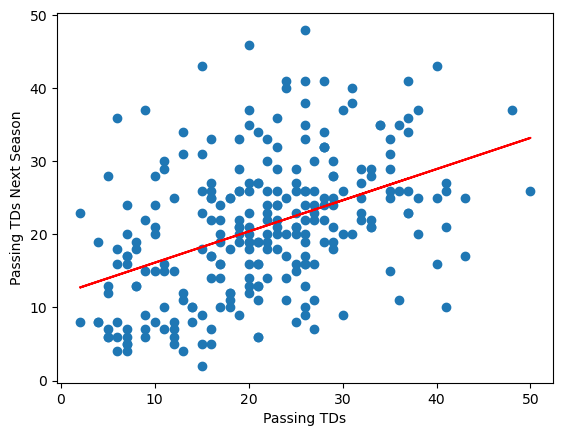

In [ ]:
X = df[['pass_touchdowns']]
y = df['touchdowns_next']

m, b = np.polyfit(df['pass_touchdowns'], df['touchdowns_next'], 1)

plt.scatter(X,y)
plt.xlabel('Passing TDs')
plt.ylabel('Passing TDs Next Season')
plt.plot(X, m*X + b, color='red') 

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

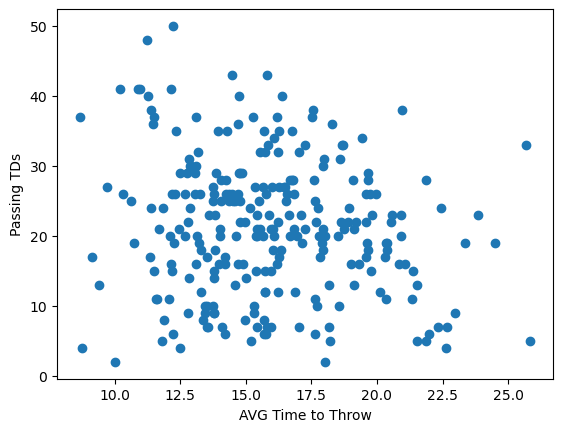

In [ ]:
X = df[['aggressiveness']]
y = df['pass_touchdowns']

plt.xlabel('AVG Time to Throw')
plt.ylabel('Passing TDs')
plt.scatter(X,y)
plt.show

In [ ]:
# How to use model output
# Sam Darnold 2025 stats: 4048 pass yds, 14 ints, 25 pass tds (always add the constant)
print("predicted 2026 pass TDs:", (12.7294 + (4048 * 0.0014) + (25 * 0.3444) + (14 * -0.3743)))

# Bryce Young 2025 stats: 3011 pass yds, 11 ints, 23 pass tds
# How many TDs is Bryce Young predicted to throw in 2026?

predicted 2026 pass TDs: 21.766399999999997


In [ ]:
X = df[['pass_touchdowns']]
y = df['twenty_next'] # Change 1
X = X.astype(float)

X = sm.add_constant(X)
model = sm.Logit(y, X).fit() # Change 2
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.588380
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            twenty_next   No. Observations:                  261
Model:                          Logit   Df Residuals:                      259
Method:                           MLE   Df Model:                            1
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.1400
Time:                        13:06:20   Log-Likelihood:                -153.57
converged:                       True   LL-Null:                       -178.56
Covariance Type:            nonrobust   LLR p-value:                 1.552e-12
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.8883      0.364     -5.186      0.000      -2.602      -1.175
pass_touchdown

In [ ]:
X = pd.DataFrame({'pass_touchdowns': [40]})
X = sm.add_constant(X, has_constant='add')

prob = model.predict(X)
print(prob)

0    0.907011
dtype: float64
